# Lecture 2 — SARSA, Monte Carlo, and the Cost of Exploration

**Reinforcement Learning, 2025-26**

## Where we are

In Lecture 1 we built a tabular Q-learning agent and watched it solve a deterministic version of `MicrobeGridEnv`. The microbe found the cliff-edge optimal path and stayed on it — a clean victory, made possible by the fact that nothing the microbe did could ever go wrong: every commanded action was executed exactly as intended.

The world is rarely that obliging. Most environments — from a mobile robot on a real floor to a player in a card game to a trading agent in a noisy market — are **stochastic**: the same action in the same state can produce different outcomes. We will spend today understanding how stochasticity changes the picture, and we will meet two new families of model-free agents — **SARSA** and **Monte Carlo** — that handle the resulting uncertainty in qualitatively different ways from Q-learning.

## What you will learn today

By the end of this lecture you will be able to:

1. Distinguish **on-policy** from **off-policy** model-free control, and explain why the same observed transition produces different updates under SARSA and Q-learning.
2. Implement and train tabular **SARSA** and **Monte Carlo** agents (both first-visit and every-visit) using the same `Agent` interface and training loop introduced in Lecture 1.
3. Diagnose three model-free methods on the same problem — comparing their **learning curves**, their **learned policies**, and their **bias–variance trade-offs** — and reason about which method to choose in which regime.

## How we will get there

We open with a side-by-side comparison: Q-learning on the deterministic environment of Lecture 1, against Q-learning on a stochastic version of the same environment with `slippery = 0.2`. The contrast motivates the rest of the lecture, by exposing how the same algorithm behaves differently in the presence of irreducible noise. We then introduce SARSA as a small but consequential modification of Q-learning, train it on the stochastic environment, and compare the two agents directly. After a short break we introduce Monte Carlo control, contrasting it with the temporal-difference family along the bias–variance axis. We close by putting the three methods on a single grid and reading what they have learned.

The agents we build today live in `rlc/agents/sarsa.py` and `rlc/agents/monte_carlo.py`; the training loop, plotting helpers, and `MicrobeGridEnv` are reused unchanged from Lecture 1.

## Experimental setup

The lecture compares several agents on the same environment under controlled conditions. To keep the comparison fair and the notebook readable, all hyperparameters and environment configurations are gathered in the cell below — a single source of truth for everything that follows. The training schedule, the random seed, and the parameters of the three agents are defined once and reused throughout the notebook. Whenever you want to experiment with a different setting, this is the cell to edit.

We use a slightly larger habitat than in Lecture 1 — six rows instead of four — to give SARSA enough room to learn a visibly distinct trajectory from Q-learning. The toxic band still occupies the bottom row between start and goal, matching the standard Cliff Walking layout of Sutton & Barto.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

from rlc.envs.microbe import MicrobeGridEnv
from rlc.agents.q_learning import QLearningAgent
from rlc.utils.training import train, evaluate
from rlc.utils.plotting import plot_learning_curves, plot_grid_policy_and_values

# ============================================================================
# Environment configurations
# ============================================================================
# A 6 x 12 habitat with a row of toxic cells along the bottom edge,
# between start (5, 0) and goal (5, 11). The deterministic and stochastic
# variants share everything except the slippery parameter.

_GRID_HEIGHT = 6
_GRID_WIDTH = 12
_TOXIC_CELLS = [(5, c) for c in range(1, 11)]
_START_POS = (5, 0)
_GOAL_POS = (5, 11)

ENV_DET = dict(
    height=_GRID_HEIGHT,
    width=_GRID_WIDTH,
    start_pos=_START_POS,
    goal_pos=_GOAL_POS,
    toxic_cells=_TOXIC_CELLS,
    slippery=0.0,
    render_mode="rgb_array",
)

ENV_SLIP = dict(
    height=_GRID_HEIGHT,
    width=_GRID_WIDTH,
    start_pos=_START_POS,
    goal_pos=_GOAL_POS,
    toxic_cells=_TOXIC_CELLS,
    slippery=0.2,
    render_mode="rgb_array",
)

# ============================================================================
# Training schedule
# ============================================================================
N_EPISODES = 2000
EVAL_EVERY = 50
EVAL_EPISODES = 20
MAX_STEPS_PER_EPISODE = 500
EVAL_MAX_STEPS = 500
MASTER_SEED = 42

# ============================================================================
# Agent hyperparameters
# ============================================================================
# Q-learning and SARSA share the same hyperparameter schedule, so that any
# difference observed in their behaviour can be attributed to the algorithm
# itself and not to incidental tuning.

_TD_PARAMS = dict(
    alpha=0.1,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.997,
)

Q_PARAMS = dict(_TD_PARAMS)
SARSA_PARAMS = dict(_TD_PARAMS)

## Q-learning under uncertainty

Before introducing new algorithms, let us see what happens to the algorithm we already know when we add stochasticity to the environment. We train two Q-learning agents — one on the deterministic `MicrobeGridEnv` of Lecture 1, one on a stochastic version with `slippery = 0.2` — using identical hyperparameters and identical training schedules. The agents are otherwise indistinguishable; only the world they inhabit differs.

## A small detour: Gymnasium wrappers and visit counts

Before introducing SARSA, we take a brief detour to look at *what the agent has actually seen* during training. The two Q-learning agents trained above produced learning curves and policies; what they did *not* tell us is how the experience was distributed across the grid — which cells the agent visited often, which it visited rarely, which it perhaps never visited at all. This information is diagnostic gold: it grounds abstract conditions like the GLIE assumption (every state-action pair must be visited infinitely often) in something concrete, and it reveals an asymmetry in the data on which the Q-table is trained — an asymmetry that shapes what the algorithm can and cannot learn.

To collect this information cleanly, we use a feature of Gymnasium we have mentioned but not yet exercised: **wrappers**. A wrapper is a class that *wraps* an existing environment, exposing the same interface but adding behaviour around it — logging, normalization, time limits, frame stacking, and many others ship with the library, and you can write your own. We will write our own now, both because we need it and because it is the most natural way to introduce the wrapper pattern.

### The wrapper pattern

A Gymnasium wrapper is any subclass of `gymnasium.Wrapper`. It receives the inner environment in its constructor, stores it as `self.env`, and inherits the full `Env` API automatically. By default, every method call (`reset`, `step`, `render`, `close`, ...) is delegated transparently to the inner environment. To add behaviour, you override only the methods you want to change, calling `super().method(...)` to delegate to the inner environment as needed. The wrapper is therefore *additive* — it never reimplements the underlying environment, it only intercepts and augments calls.

The result is composable: wrappers can be stacked, each adding one well-defined transformation. We saw this in Lecture 1 when `gym.make` returned `<OrderEnforcing<PassiveEnvChecker<CliffWalkingEnv>>>` — three layers of wrappers, one inside the other, each adding a small piece of behaviour around the bare environment. We will not stack ours today, but the principle is the same: each wrapper is a single concern.

### What our wrapper does

We want to record, for every transition during training, the state-action pair that produced it. Concretely: a matrix $N \in \mathbb{N}^{|\mathcal{S}| \times |\mathcal{A}|}$, initialized to zero, with $N[s, a]$ incremented every time the agent takes action $a$ in state $s$. From this we can derive the marginal $N(s) = \sum_a N(s, a)$, the number of times the agent has *visited* state $s$, regardless of which action it then took.

The implementation involves two methods. `reset` records the initial state of every episode. `step` records the (state, action) pair at every transition and updates the tracked current state to the next observation. The matrix is exposed via a public attribute that any external code (a notebook cell, a plotting function) can read at any point during or after training.

You may have noticed, looking back at the first training cell, that `MicrobeGridEnv` was already wrapped — the cell read `env_q_det = VisitCountWrapper(MicrobeGridEnv(**ENV_DET))`. The wrapper has been quietly counting every transition for the entire duration of training. We just had to *explain* it before *using* it; let us now do that, and then come back to read the counters.

In [2]:
from rlc.envs.visit_count import VisitCountWrapper

# Deterministic environment, wrapped to track (s, a) visit counts.
env_q_det = VisitCountWrapper(MicrobeGridEnv(**ENV_DET))
eval_env_q_det = MicrobeGridEnv(**ENV_DET)
agent_q_det = QLearningAgent(
    n_states=env_q_det.observation_space.n,
    n_actions=env_q_det.action_space.n,
    seed=MASTER_SEED + 1,
    **Q_PARAMS,
)
hist_q_det = train(
    agent_q_det, env_q_det,
    n_episodes=N_EPISODES,
    max_steps_per_episode=MAX_STEPS_PER_EPISODE,
    eval_every=EVAL_EVERY,
    eval_episodes=EVAL_EPISODES,
    eval_env=eval_env_q_det,
    eval_max_steps=EVAL_MAX_STEPS,
    seed=MASTER_SEED,
    progress=True,
)

# Stochastic environment (slippery = 0.2), wrapped likewise.
env_q_slip = VisitCountWrapper(MicrobeGridEnv(**ENV_SLIP))
eval_env_q_slip = MicrobeGridEnv(**ENV_SLIP)
agent_q_slip = QLearningAgent(
    n_states=env_q_slip.observation_space.n,
    n_actions=env_q_slip.action_space.n,
    seed=MASTER_SEED + 2,
    **Q_PARAMS,
)
hist_q_slip = train(
    agent_q_slip, env_q_slip,
    n_episodes=N_EPISODES,
    max_steps_per_episode=MAX_STEPS_PER_EPISODE,
    eval_every=EVAL_EVERY,
    eval_episodes=EVAL_EPISODES,
    eval_env=eval_env_q_slip,
    eval_max_steps=EVAL_MAX_STEPS,
    seed=MASTER_SEED,
    progress=True,
)

print(f"Deterministic: final eval return = {hist_q_det.eval_mean_returns[-1]:6.1f}  "
      f"(std {hist_q_det.eval_std_returns[-1]:.1f})")
print(f"Slippery 0.2:  final eval return = {hist_q_slip.eval_mean_returns[-1]:6.1f}  "
      f"(std {hist_q_slip.eval_std_returns[-1]:.1f})")

Training:   0%|          | 0/2000 [00:00<?, ?ep/s]

Training:   0%|          | 0/2000 [00:00<?, ?ep/s]

Deterministic: final eval return =  -13.0  (std 0.0)
Slippery 0.2:  final eval return =  -33.2  (std 12.4)


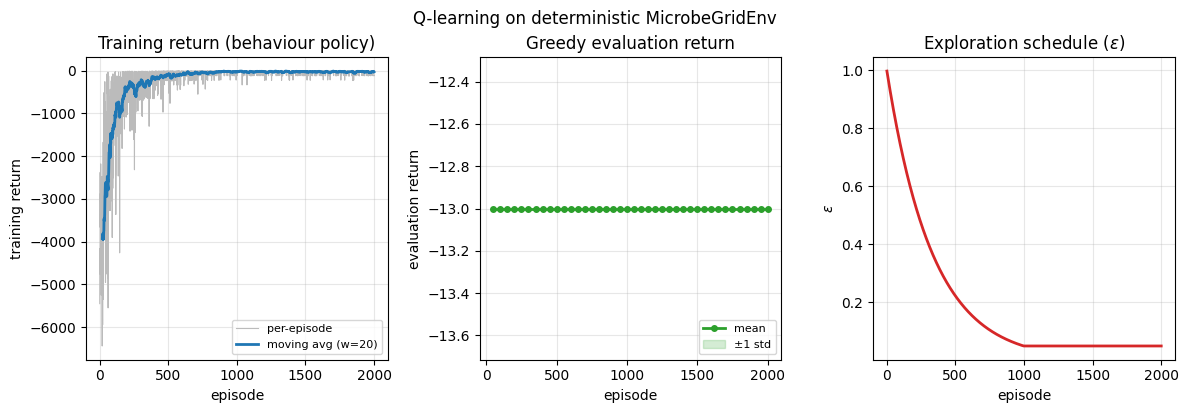

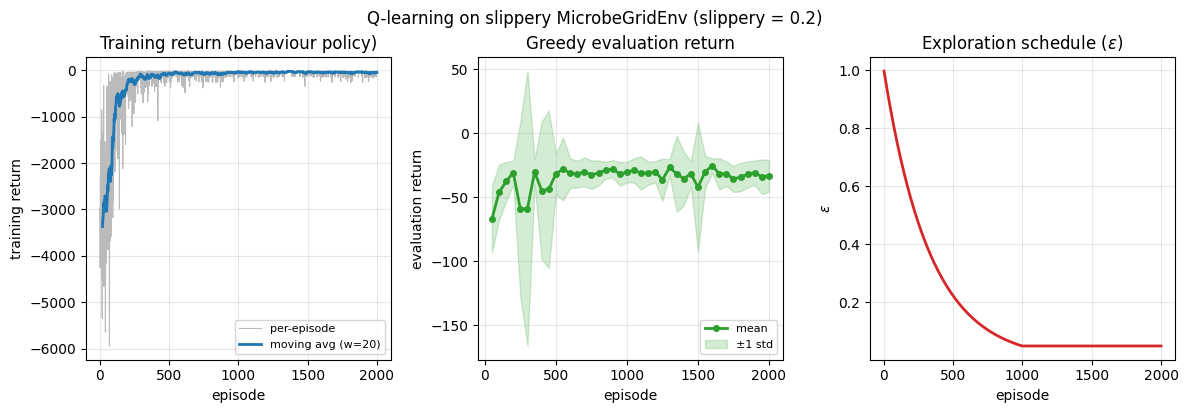

In [3]:
fig_det = plot_learning_curves(hist_q_det)
fig_det.suptitle("Q-learning on deterministic MicrobeGridEnv", y=1.02)
plt.show()

fig_slip = plot_learning_curves(hist_q_slip)
fig_slip.suptitle("Q-learning on slippery MicrobeGridEnv (slippery = 0.2)", y=1.02)
plt.show()

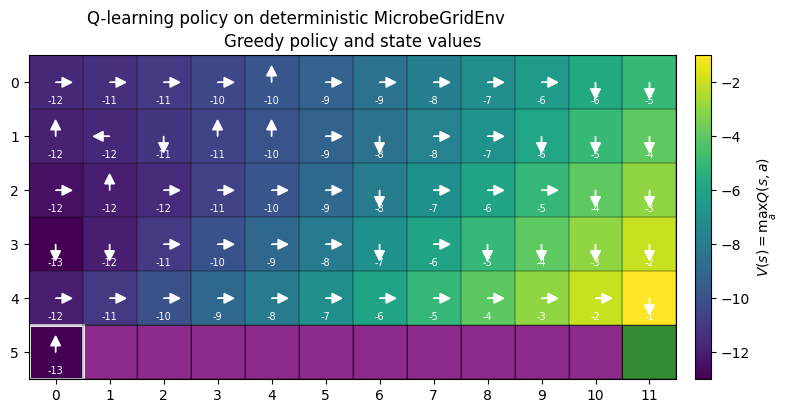

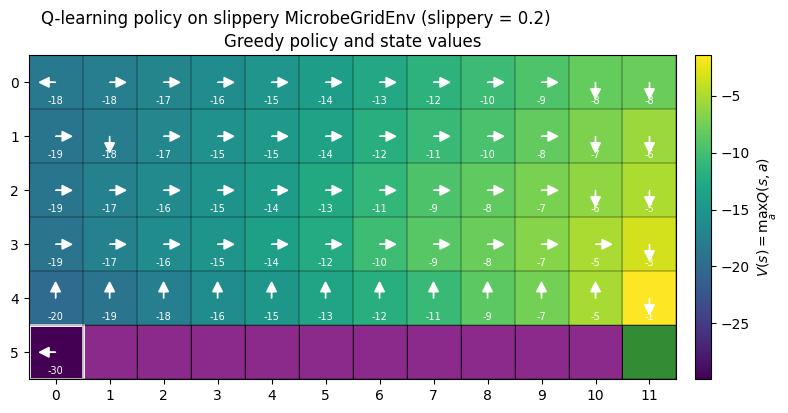

In [4]:
fig_pol_det = plot_grid_policy_and_values(agent_q_det, env_q_det, annotate_values=True)
fig_pol_det.suptitle("Q-learning policy on deterministic MicrobeGridEnv", y=1.02)
plt.show()

fig_pol_slip = plot_grid_policy_and_values(agent_q_slip, env_q_slip, annotate_values=True)
fig_pol_slip.suptitle("Q-learning policy on slippery MicrobeGridEnv (slippery = 0.2)", y=1.02)
plt.show()

### Visited states and actions

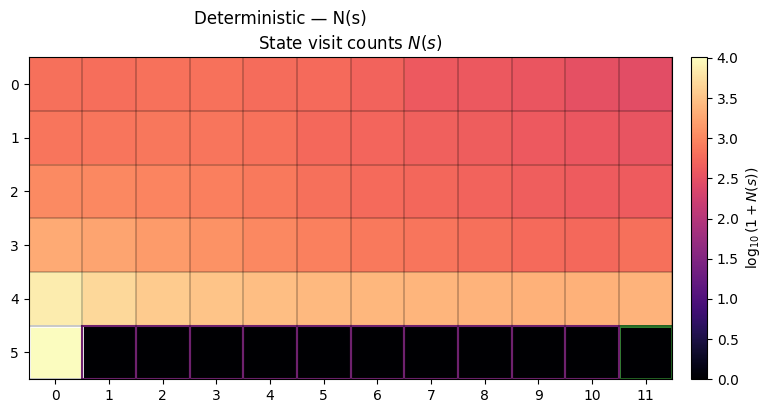

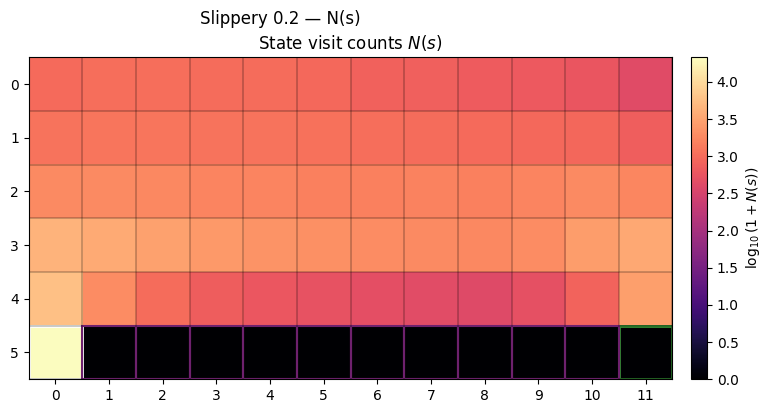

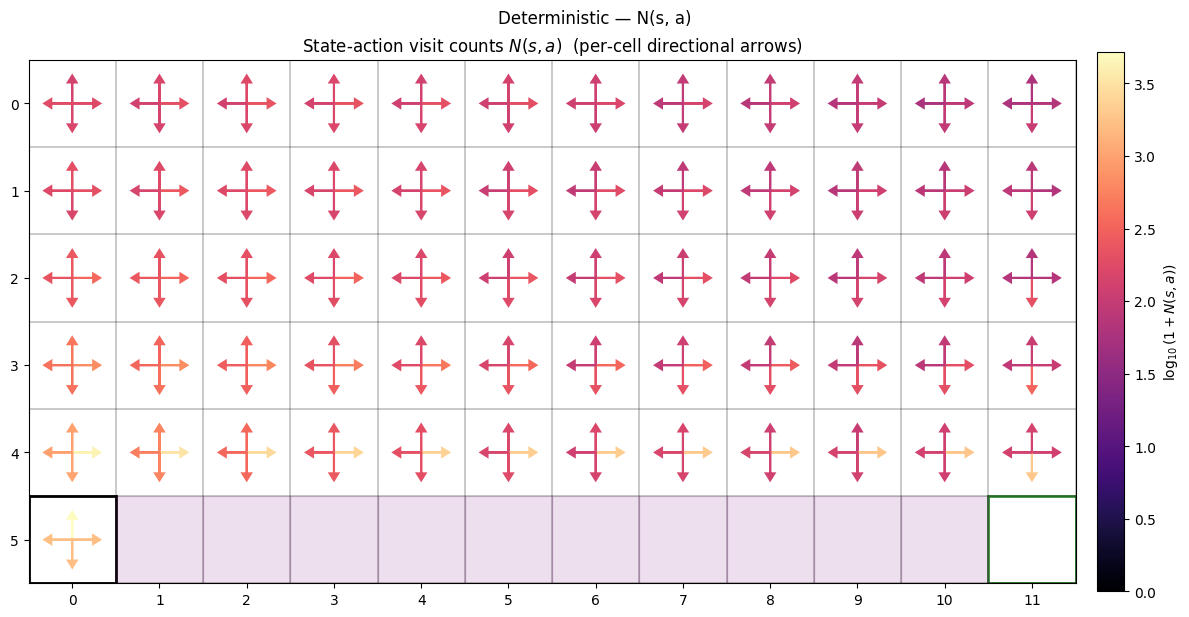

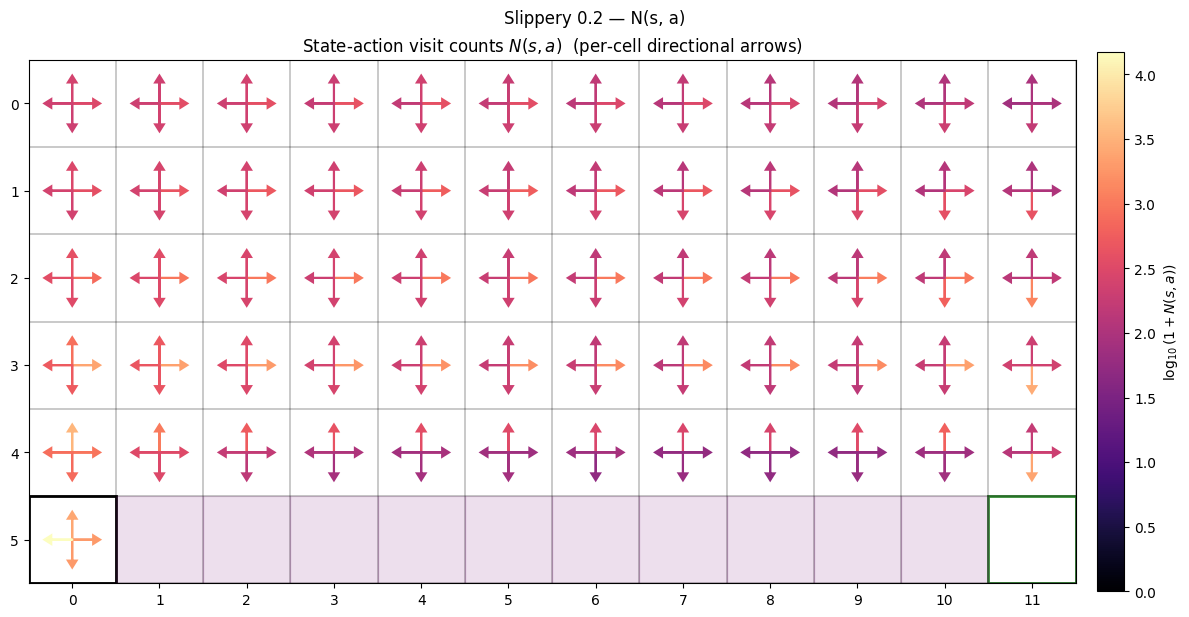

Deterministic: min N(s,a) over reachable pairs = 55, never-visited pairs = 0
Slippery 0.2:  min N(s,a) over reachable pairs = 49, never-visited pairs = 0


In [5]:
from rlc.utils.plotting import plot_state_visits, plot_state_action_visits

# Get the inner MicrobeGridEnv for layout (env_q_det is the wrapper).
inner_det = env_q_det.unwrapped
inner_slip = env_q_slip.unwrapped

# State visits
fig = plot_state_visits(env_q_det.state_action_counts, inner_det)
fig.suptitle("Deterministic — N(s)", y=1.02)
plt.show()

fig = plot_state_visits(env_q_slip.state_action_counts, inner_slip)
fig.suptitle("Slippery 0.2 — N(s)", y=1.02)
plt.show()

# State-action visits
fig = plot_state_action_visits(env_q_det.state_action_counts, inner_det)
fig.suptitle("Deterministic — N(s, a)", y=1.02)
plt.show()

fig = plot_state_action_visits(env_q_slip.state_action_counts, inner_slip)
fig.suptitle("Slippery 0.2 — N(s, a)", y=1.02)
plt.show()

# Diagnostic: minimum visit count over all (s, a) reachable.
def min_visit_diag(counts: np.ndarray, env: "MicrobeGridEnv") -> tuple[int, int]:
    """Return (min count over reachable (s,a), number of (s,a) never visited)."""
    H, W = env.height, env.width
    reachable_mask = np.ones((H, W), dtype=bool)
    for (r, c) in env.toxic_cells:
        reachable_mask[r, c] = False
    gr, gc = env.goal_pos
    reachable_mask[gr, gc] = False  # goal is terminal: no action ever taken from it
    reachable_states = np.flatnonzero(reachable_mask.ravel())
    sub = counts[reachable_states]
    return int(sub.min()), int((sub == 0).sum())

m_det, z_det = min_visit_diag(env_q_det.state_action_counts, inner_det)
m_slip, z_slip = min_visit_diag(env_q_slip.state_action_counts, inner_slip)
print(f"Deterministic: min N(s,a) over reachable pairs = {m_det}, "
      f"never-visited pairs = {z_det}")
print(f"Slippery 0.2:  min N(s,a) over reachable pairs = {m_slip}, "
      f"never-visited pairs = {z_slip}")

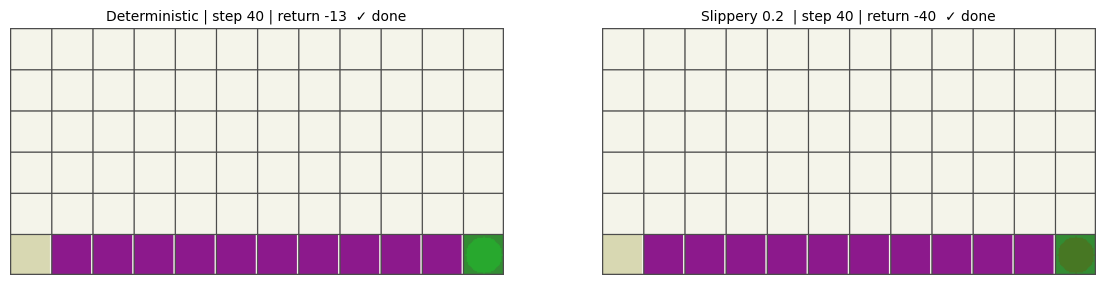

Deterministic episode: return = -13
Slippery episode:      return = -40


In [6]:
def show_two_frames(frame_left, title_left, frame_right, title_right):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].imshow(frame_left)
    axes[0].axis("off")
    axes[0].set_title(title_left, fontsize=10)
    axes[1].imshow(frame_right)
    axes[1].axis("off")
    axes[1].set_title(title_right, fontsize=10)
    plt.show()

FRAME_DELAY = 0.3
ROLLOUT_MAX_STEPS = 60

env_left = MicrobeGridEnv(**ENV_DET)
env_right = MicrobeGridEnv(**ENV_SLIP)

obs_l, _ = env_left.reset(seed=MASTER_SEED + 100)
obs_r, _ = env_right.reset(seed=MASTER_SEED + 100)
ret_l, ret_r = 0.0, 0.0
done_l, done_r = False, False
step = 0

show_two_frames(
    env_left.render(),
    f"Deterministic | step 0 | return 0",
    env_right.render(),
    f"Slippery 0.2  | step 0 | return 0",
)
time.sleep(FRAME_DELAY)

for _ in range(ROLLOUT_MAX_STEPS):
    if not done_l:
        a_l = agent_q_det.select_action(obs_l, greedy=True)
        obs_l, r_l, term_l, trunc_l, _ = env_left.step(a_l)
        ret_l += r_l
        done_l = term_l or trunc_l
    if not done_r:
        a_r = agent_q_slip.select_action(obs_r, greedy=True)
        obs_r, r_r, term_r, trunc_r, _ = env_right.step(a_r)
        ret_r += r_r
        done_r = term_r or trunc_r

    step += 1
    clear_output(wait=True)
    show_two_frames(
        env_left.render(),
        f"Deterministic | step {step} | return {ret_l:.0f}"
        + ("  ✓ done" if done_l else ""),
        env_right.render(),
        f"Slippery 0.2  | step {step} | return {ret_r:.0f}"
        + ("  ✓ done" if done_r else ""),
    )
    time.sleep(FRAME_DELAY)

    if done_l and done_r:
        break

env_left.close()
env_right.close()

print(f"Deterministic episode: return = {ret_l:.0f}")
print(f"Slippery episode:      return = {ret_r:.0f}")

The animation makes the abstract observation concrete. The deterministic microbe walks the cliff edge with the calm confidence of a system that knows the world will obey it. The slippery one walks the same cliff edge — same policy, same arrows on the grid — and pays a price every few episodes when the world reminds it that it does not. Q-learning has no language to express this difference: its target asks "what is the value of the greedy action at the next state?" and the answer is the same in both worlds, ignoring the noise that the agent is about to be pushed through.

The next section introduces an algorithm that tells a different story. SARSA's target asks instead "what is the value of the action the agent will *actually* take next?" — and that single change in the question changes the answer.

# SARSA: on-policy temporal-difference control

We left the previous section with a question. Q-learning's update used $\max_{a'} Q(S_{t+1}, a')$, the value of the *greedy* action at the next state, regardless of which action the agent will actually take next under its $\varepsilon$-greedy behaviour. This made the value function tell a slightly schizophrenic story on stochastic problems: the *greedy policy* was the cliff-edge optimum (right along the toxic band) while the *value function* honestly reported the expected cost of trying to follow that policy in a world where slips occasionally pushed the microbe off course.

SARSA changes the question. Instead of asking *"what is the value of the greedy action at the next state?"*, it asks *"what is the value of the action the agent will actually take next?"*. The change is a single symbol in the update rule, and yet it flips the entire interpretation of what is being learned.

### The SARSA update

After a transition $(S_t, A_t, R_{t+1}, S_{t+1})$, SARSA needs one extra ingredient that Q-learning does not: the action $A_{t+1}$ that the *behaviour policy* selects in the new state $S_{t+1}$. Once that action is sampled — typically with the same $\varepsilon$-greedy rule used to select $A_t$ — the update is

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[ \underbrace{R_{t+1} + \gamma \, Q(S_{t+1}, A_{t+1})}_{\text{TD target}} - Q(S_t, A_t) \right].$$

The bootstrap term has changed: $\max_{a'} Q(S_{t+1}, a')$ is replaced by $Q(S_{t+1}, A_{t+1})$, where $A_{t+1}$ is the actual next action the agent commits to take. The terminal-state rule is unchanged — when $S_{t+1}$ is terminal in the MDP sense, the bootstrap factor is zero and the target collapses to $R_{t+1}$.

The name "SARSA" is a mnemonic for the five quantities involved in one update: $S, A, R, S', A'$. Q-learning, by contrast, would be "SARS-max", as it uses only $S, A, R, S'$ plus a maximization over actions at $S'$.

### Why the difference matters: on-policy vs. off-policy

Q-learning learns the action-value function of the *greedy* policy with respect to the current $Q$, while behaving according to a different (more exploratory) policy. The behaviour policy is used only to *generate* transitions; the target reflects what the *greedy* policy would do. This decoupling of the policy being learned from the policy being followed is the technical sense of **off-policy** control.

SARSA learns the action-value function of the *behaviour policy itself*. Both the action that produced the transition and the action used in the target are samples from the same $\varepsilon$-greedy policy. The target reflects what the *current* policy will actually do at the next step, including the random exploratory deviations. This alignment of the policy being learned and the policy being followed is the technical sense of **on-policy** control.

The consequence is concrete and visible on stochastic problems. SARSA's value function does not pretend that exploration will not happen; it absorbs the cost of $\varepsilon$-greedy randomness into the values themselves. Cells from which a random action would be expensive — like those adjacent to the toxic band — receive *lower* values than they would under Q-learning, because under SARSA's behaviour policy there is a real chance, $\varepsilon / |\mathcal{A}|$, of stepping into the toxic band purely by exploration. Q-learning's target ignores this contribution by always evaluating the greedy action.

When the same policy improvement step (greedy with respect to the current $Q$, then $\varepsilon$-greedy on top) is then applied to these different value functions, it produces different policies. SARSA prefers states whose neighbourhoods are *robust to the agent's own exploration*, because those are the states that look good under its target. Q-learning prefers states whose neighbourhoods are *optimal under perfect play*, because those are the states that look good under its target.

### What converges to what

Under the same standard conditions we discussed for Q-learning — finite MDP, every state-action pair visited infinitely often, learning rate satisfying the Robbins–Monro conditions, and a GLIE behaviour policy ($\varepsilon \to 0$) — SARSA's table converges almost surely to $q_\star$, the optimal action-value function. So in the limit the two algorithms agree. The point is that they take different paths to get there, and during the entire transient — which is to say, during all of training — they make qualitatively different decisions.

This is not a defect of either method. It is a reflection of the fact that they are answering different questions, and the answers happen to coincide only when the question itself becomes vacuous (when $\varepsilon$ has already gone to zero, and the agent no longer explores).

### Q-learning vs. SARSA, side by side

Six points are worth keeping in mind as we move to the implementation and the empirical comparison.

1. **The update rule differs in one symbol.** Q-learning uses $\max_{a'} Q(S', a')$; SARSA uses $Q(S', A')$ where $A'$ is sampled from the behaviour policy.

2. **The information needed differs slightly.** Q-learning's update needs $(S, A, R, S')$; SARSA's update needs $(S, A, R, S', A')$. SARSA must therefore commit to the next action *before* its current update.

3. **Off-policy vs. on-policy.** Q-learning evaluates one policy (greedy w.r.t. $Q$) while behaving according to another ($\varepsilon$-greedy). SARSA evaluates the behaviour policy itself.

4. **The value functions differ during training.** SARSA's values are systematically lower than Q-learning's near risky states, because they incorporate the cost of behaviour-policy exploration. Q-learning's values are "optimistic" in the same sense, ignoring exploration.

5. **The learned policies differ during training.** SARSA learns a *more conservative* greedy policy that stays away from regions where exploration is costly; Q-learning learns the *cliff-edge* greedy policy that ignores the cost of nearby slips and explorations.

6. **The two converge to the same limit.** As $\varepsilon \to 0$ both algorithms target $q_\star$ and recover the optimal policy. The difference matters during the transient, which in practical RL is always.

We now make these claims operational. The next cell implements SARSA as a small variant of `QLearningAgent`, and the section after that runs both agents on the slippery environment and compares them along the three lenses we have already used: learning curves, learned policies, and a side-by-side animated rollout.

## SARSA on slippery

In [7]:
from rlc.agents.sarsa import SARSAAgent

env_sarsa_slip = VisitCountWrapper(MicrobeGridEnv(**ENV_SLIP))
eval_env_sarsa_slip = MicrobeGridEnv(**ENV_SLIP)

agent_sarsa_slip = SARSAAgent(
    n_states=env_sarsa_slip.observation_space.n,
    n_actions=env_sarsa_slip.action_space.n,
    seed=MASTER_SEED + 3,
    **SARSA_PARAMS,
)

hist_sarsa_slip = train(
    agent_sarsa_slip, env_sarsa_slip,
    n_episodes=N_EPISODES,
    max_steps_per_episode=MAX_STEPS_PER_EPISODE,
    eval_every=EVAL_EVERY,
    eval_episodes=EVAL_EPISODES,
    eval_env=eval_env_sarsa_slip,
    eval_max_steps=EVAL_MAX_STEPS,
    seed=MASTER_SEED,
    progress=True,
)

print(f"SARSA on slippery 0.2: final eval return = "
      f"{hist_sarsa_slip.eval_mean_returns[-1]:6.1f}  "
      f"(std {hist_sarsa_slip.eval_std_returns[-1]:.1f})")
print(f"  final epsilon: {agent_sarsa_slip.epsilon:.3f}")

Training:   0%|          | 0/2000 [00:00<?, ?ep/s]

SARSA on slippery 0.2: final eval return =  -26.4  (std 4.1)
  final epsilon: 0.050


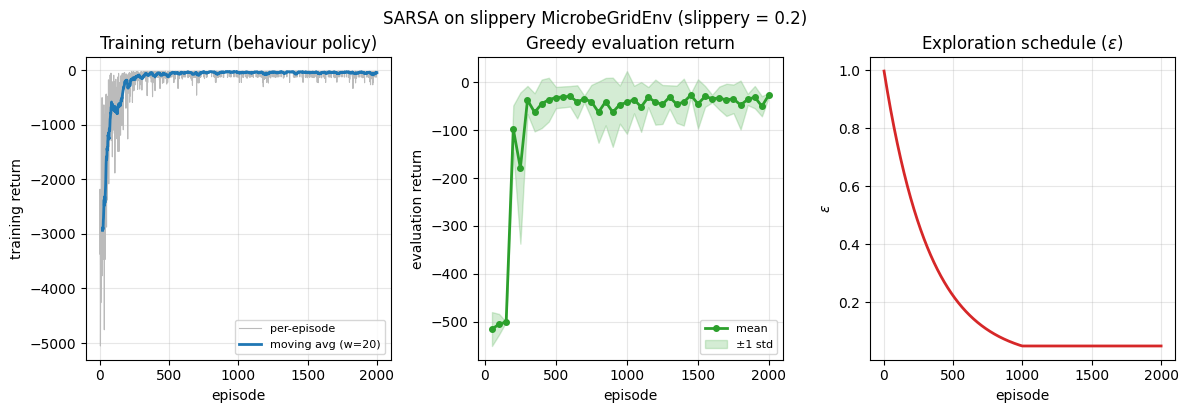

In [8]:
fig = plot_learning_curves(hist_sarsa_slip)
fig.suptitle("SARSA on slippery MicrobeGridEnv (slippery = 0.2)", y=1.02)
plt.show()

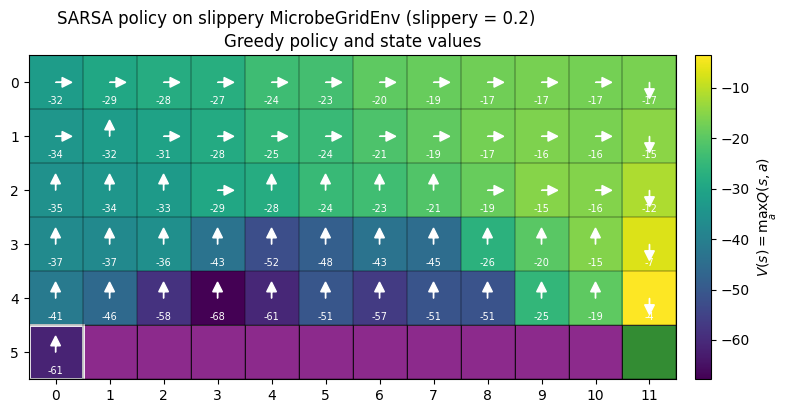

In [9]:
fig = plot_grid_policy_and_values(agent_sarsa_slip, env_sarsa_slip,
                                  annotate_values=True)
fig.suptitle("SARSA policy on slippery MicrobeGridEnv (slippery = 0.2)", y=1.02)
plt.show()

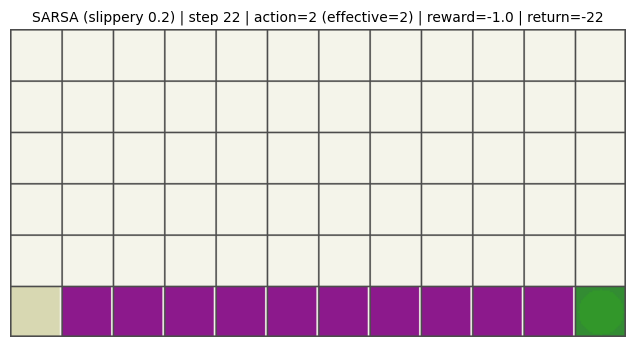

Episode ended after 22 steps with return -22.


In [10]:
def show_frame(frame, title):
    plt.figure(figsize=(10, 4))
    plt.imshow(frame)
    plt.axis("off")
    plt.title(title, fontsize=10)
    plt.show()

FRAME_DELAY = 0.3
ROLLOUT_MAX_STEPS = 80

env_demo = MicrobeGridEnv(**ENV_SLIP)
obs, _ = env_demo.reset(seed=MASTER_SEED + 200)
ep_step, ep_return = 0, 0.0

show_frame(env_demo.render(),
           title=f"SARSA (slippery 0.2) | step 0 | return 0")
time.sleep(FRAME_DELAY)

for _ in range(ROLLOUT_MAX_STEPS):
    action = agent_sarsa_slip.select_action(obs, greedy=True)
    obs, reward, terminated, truncated, info = env_demo.step(action)
    ep_step += 1
    ep_return += reward

    clear_output(wait=True)
    show_frame(
        env_demo.render(),
        title=(f"SARSA (slippery 0.2) | step {ep_step} | "
               f"action={action} (effective={info['effective_action']}) | "
               f"reward={reward} | return={ep_return:.0f}")
    )
    time.sleep(FRAME_DELAY)

    if terminated or truncated:
        break

env_demo.close()
print(f"Episode ended after {ep_step} steps with return {ep_return:.0f}.")

## SARSA vs. Q-learning, side by side

We have read SARSA in isolation. We now place it next to Q-learning, on the *same* slippery environment, with *identical* hyperparameters and identical training schedules — the conditions under which any difference observed must be attributed to the algorithm itself.

The comparison proceeds along two lenses, in the order announced earlier in the lecture: first the state values and the greedy policies, then the convergence behaviour as captured by the greedy evaluation curves.

### State values and greedy policies

The two policy plots below share a colour scale, so that values can be compared directly between cells of the same colour across the two grids. Toxic and goal cells are masked from the colormap and visually highlighted, as in all previous plots.

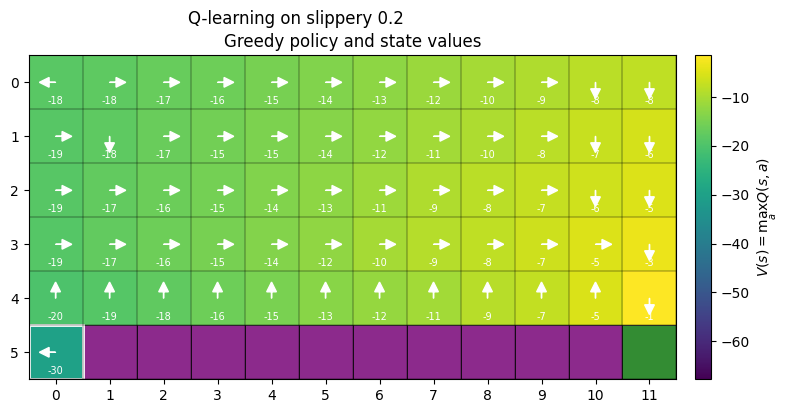

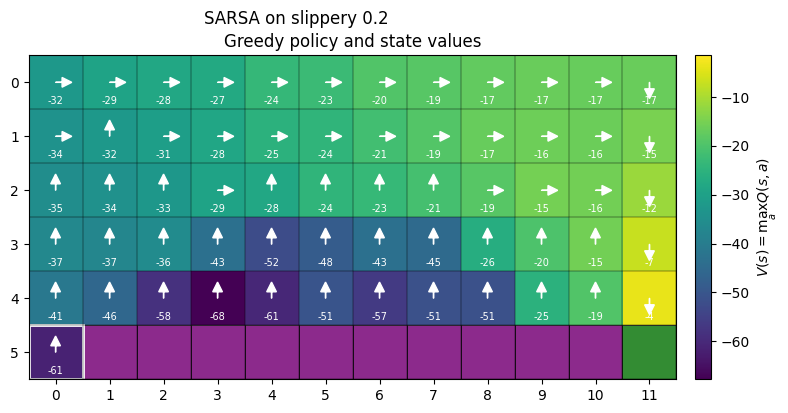

In [11]:
# Compute a shared color scale across both agents (over free, non-terminal cells).
def _free_state_values(agent, env):
    env_inner = getattr(env, "unwrapped", env)
    H, W = env_inner.height, env_inner.width
    values = agent.state_values().reshape(H, W).copy()
    for (r, c) in env_inner.toxic_cells:
        values[r, c] = np.nan
    gr, gc = env_inner.goal_pos
    values[gr, gc] = np.nan
    return values

vals_q = _free_state_values(agent_q_slip, env_q_slip)
vals_s = _free_state_values(agent_sarsa_slip, env_sarsa_slip)
shared_vmin = float(np.nanmin([np.nanmin(vals_q), np.nanmin(vals_s)]))
shared_vmax = float(np.nanmax([np.nanmax(vals_q), np.nanmax(vals_s)]))

fig_q = plot_grid_policy_and_values(
    agent_q_slip, env_q_slip,
    annotate_values=True,
    vmin=shared_vmin, vmax=shared_vmax,
)
fig_q.suptitle("Q-learning on slippery 0.2", y=1.02)
plt.show()

fig_s = plot_grid_policy_and_values(
    agent_sarsa_slip, env_sarsa_slip,
    annotate_values=True,
    vmin=shared_vmin, vmax=shared_vmax,
)
fig_s.suptitle("SARSA on slippery 0.2", y=1.02)
plt.show()

### Convergence: greedy evaluation curves

The training-return curves of the two agents are not directly comparable, because they reflect the noisy returns produced by the behaviour policy ($\varepsilon$-greedy) — a quantity that depends on $\varepsilon$ as much as on the algorithm. The clean comparison happens on the *greedy* evaluation curves, computed every `EVAL_EVERY` episodes by running the agent in greedy mode for `EVAL_EPISODES` rollouts. This isolates the quality of *what has been learned* from the cost of *exploration during training*.

We overlay the two curves with one-standard-deviation bands and complement them with a small numerical summary that captures the final return, its variance, and the episode at which each agent stabilizes (the earliest episode after which the next 5 evaluation points stay within $\pm 1.0$ of the final mean).

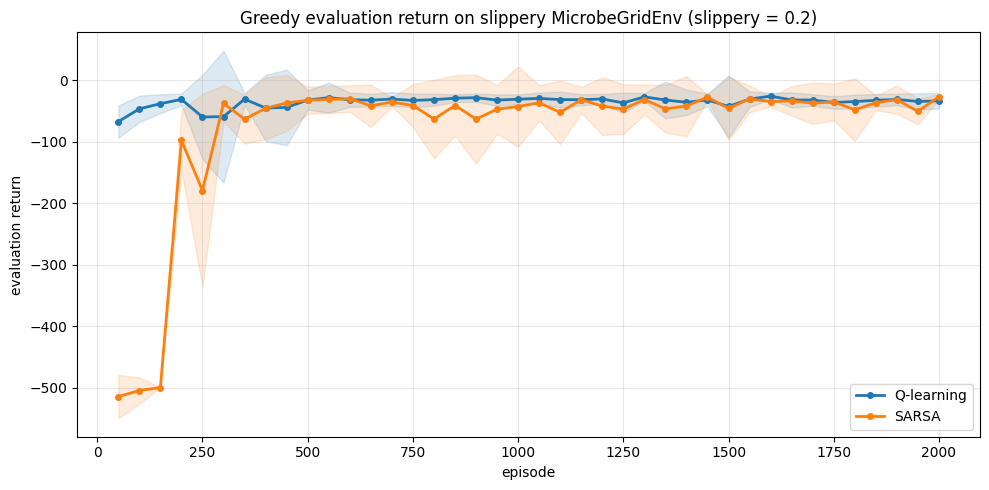

agent             final mean     final std    last-10 mean     last-10 std
----------------------------------------------------------------------------
Q-learning            -33.25         12.43          -32.05            2.70
SARSA                 -26.40          4.08          -36.19            7.11


In [12]:
from rlc.utils.plotting import plot_evaluation_curves_overlay, summarize_evaluations

histories = {
    "Q-learning": hist_q_slip,
    "SARSA":      hist_sarsa_slip,
}
fig = plot_evaluation_curves_overlay(
    histories,
    title="Greedy evaluation return on slippery MicrobeGridEnv (slippery = 0.2)",
)
plt.show()

# Numerical summary: long-run level and stability over the last 10 checkpoints.
summary = summarize_evaluations(histories, last_k=10)

print(f"{'agent':<14}{'final mean':>14}{'final std':>14}"
      f"{'last-10 mean':>16}{'last-10 std':>16}")
print("-" * 76)
for row in summary:
    print(f"{row['agent']:<14}"
          f"{row['final_mean']:>14.2f}"
          f"{row['final_std']:>14.2f}"
          f"{row['last_k_mean']:>16.2f}"
          f"{row['last_k_std']:>16.2f}")

### Two questions worth pinning down

Two questions naturally arise looking at the comparison, and they are worth answering in concise form before we move on.

**Why is SARSA more cautious?**

Because SARSA's TD target evaluates *the policy the agent is actually following*, not the policy it would follow if exploration were turned off. Concretely, the bootstrap term $Q(S_{t+1}, A_{t+1})$ uses an action $A_{t+1}$ sampled from the $\varepsilon$-greedy behaviour policy — which means that with probability $\varepsilon$ it is a random action drawn uniformly over $\mathcal{A}$. So a state from which a random action would lead to a toxic cell sees its value pulled down by a chance, equal to $\varepsilon / |\mathcal{A}|$, of incurring the toxic penalty. The cells immediately above the toxic band are precisely such states: a uniform random action has one chance in four of being "down". SARSA's Q-values absorb this *probabilistic cost of being exploratory near danger*, and the greedy policy that emerges from those Q-values prefers states where the cost of exploration is small — i.e., states far from danger.

Q-learning's TD target uses $\max_{a'} Q(S_{t+1}, a')$, which evaluates a hypothetical *fully greedy* agent. From the perspective of this target, the cells next to the toxic band are not dangerous at all: a fully greedy agent, by construction, will never randomly step into them. So Q-learning's Q-values do not penalise those cells, and its greedy policy happily traverses them. The penalty only manifests *during training*, in the lower training-return curve, but it never shows up in the value function being learned.

The difference is therefore not about the algorithms being "smarter" or "stupider": it is about *which question they answer*. SARSA answers "what is the value of acting like me, including the random exploration?". Q-learning answers "what is the value of acting greedily, ignoring the random exploration?". Both questions are legitimate; they just produce different policies during training, and on stochastic problems the SARSA-style answer happens to be more useful.

**Why does SARSA keep slightly more variance across evaluation checkpoints?**

The variance of the *long-run* evaluation curve — the `last-10 std` in the table above — measures how much the *mean* greedy-evaluation return wobbles between consecutive checkpoints late in training. It reflects how much the underlying greedy policy is still oscillating once the agent has essentially converged.

Q-learning's experience, in this environment, becomes highly concentrated along the cliff-edge path: the behaviour policy spends most of its time on cells very close to the optimal trajectory. As a result, the Q-values along that trajectory are estimated from many samples, are tightly nailed down, and the greedy policy stabilises early and barely changes from checkpoint to checkpoint. SARSA's experience, in contrast, is more spread out: its trajectories visit the upper rows more often, and several alternative *equally cautious* paths through those rows yield nearly identical Q-values. With many cells whose top action is essentially tied across alternatives, the greedy policy can flip an arrow here and there between checkpoints — without changing its character — and these small changes in policy translate to small changes in the evaluation mean from one checkpoint to the next.

This is the variance we observe across the *checkpoints*, not within a single checkpoint. Within a single checkpoint, SARSA's evaluation is in fact *less* variable than Q-learning's, because each greedy trajectory is more robust to the slippery dynamics — the `final_std` column of the summary table is the right place to see this. The two variances live at different levels and tell different stories.

A take-away worth carrying forward: when comparing two RL algorithms, it pays to ask *which* variance is being reported. Variance across rollouts under a fixed policy, variance across checkpoints during training, and variance across independent training runs (which we are not measuring today) are three distinct quantities and they generally do not move together.

# From TD to Monte Carlo: a question of variance

The variance discussion at the end of the previous section split a single word — *variance* — into three distinct quantities that live at different levels of the experiment: variance across rollouts under a fixed policy, variance across evaluation checkpoints during training, and variance across independent training runs. There is a fourth variance that we left unmentioned, and it is the one that connects everything we have done so far to what comes next.

Every learning algorithm we have written updates its Q-table by pulling each entry $Q(S_t, A_t)$ towards a *learning target* — the right-hand side of the update minus the bootstrap subtraction. The target is itself a random quantity: it is computed from random transitions, and the agent uses it as if it were the truth. The *variance of the learning target* is therefore a property of the algorithm, not of the experiment, and it shapes how much each gradient-style nudge moves the Q-table.

For Q-learning and SARSA the target is a *one-step* quantity:

$$T_t^{\text{TD}} = R_{t+1} + \gamma \cdot \texttt{[next-state value]}.$$

The "next-state value" is either $\max_{a'} Q(S_{t+1}, a')$ or $Q(S_{t+1}, A_{t+1})$, depending on whether we are off-policy or on-policy, but in both cases the target depends on the transition just taken plus a *current estimate* — the existing Q-table — for everything that comes after. This makes the target *low-variance* (only one stochastic transition contributes to it directly) but *biased* (it relies on Q-values that are themselves still wrong during learning). This is the bias–variance signature of the **temporal-difference (TD)** family.

There is an entirely different way to estimate $q(s, a)$ from experience, and it is the one we will study next. Wait until the *episode* is over, observe the actual return obtained from time $t$ onwards,

$$T_t^{\text{MC}} = G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \dots + \gamma^{T-t-1} R_T,$$

and use *that* as the learning target. This is the **Monte Carlo (MC)** target. It is an unbiased estimator of $q^\pi(s, a)$ when actions are sampled from the policy $\pi$, because the expectation of $G_t$ given $(S_t, A_t)$ is, by definition, $q^\pi(S_t, A_t)$ — no bootstrapping, no reliance on the current Q-table. But it is a sum of many random rewards, and its variance scales with the length and stochasticity of the episode. A long, slippery, unpredictable episode produces a wildly variable $G_t$; a short, deterministic episode produces a tightly concentrated one.

We have therefore arrived at a clean dichotomy. **TD is biased and low-variance; MC is unbiased and high-variance.** Neither dominates the other — which one performs better on a given problem depends on how much each weakness costs in that specific setting. The next section turns this into algorithm and code, and the section after that lets us see the trade-off play out empirically on the slippery microbe environment.

## Monte Carlo control: learning from complete returns

Monte Carlo methods estimate $q^\pi(s, a)$ by averaging actual returns observed under $\pi$. The estimator is a sample mean: every time the agent visits $(s, a)$ in some episode and observes the return $G$ from that visit onwards, the mean of all such returns approaches $q^\pi(s, a)$ as more episodes are collected. There is no bootstrapping, no Q-table on the right-hand side of the update.

### Algorithm: every-visit and first-visit

After an episode terminates and we have the trajectory $(S_0, A_0, R_1, S_1, A_1, R_2, \dots, S_{T-1}, A_{T-1}, R_T)$, we compute the return at every time step. Walking the trajectory backwards, with $G_T = 0$ at the terminal,

$$G_t = R_{t+1} + \gamma G_{t+1}, \qquad t = T-1, T-2, \dots, 0,$$

is the standard recursive form — efficient and numerically clean.

We then update the Q-table by averaging the $G_t$'s observed at each $(S_t, A_t)$ visit. Two textbook variants exist, differing in *which* visits within an episode are counted.

**Every-visit MC** uses every step of the trajectory: each $(S_t, A_t, G_t)$ contributes to the running average for $Q(S_t, A_t)$, even if the same state-action pair occurs multiple times in the same episode. This is straightforward to implement and uses every available sample.

**First-visit MC** uses, for each $(s, a)$ that occurs in the episode, only the *first* time it is visited: subsequent occurrences within the same episode are ignored. This is the historically older variant, and the one with the cleanest theoretical guarantees — the resulting estimator is the average of independent samples (one per episode in which $(s, a)$ occurs at least once), which makes its statistical analysis straightforward.

Both variants converge to $q^\pi(s, a)$ as the number of episodes grows; they differ in finite-sample behaviour. Every-visit MC has a small bias in finite samples (because the multiple uses of the same trajectory are correlated) but typically lower variance; first-visit MC is unbiased but discards data. On problems where each state-action pair occurs at most once per episode — many grid worlds qualify — the two variants coincide.

### The incremental update

Maintaining a running average is more memory-friendly than storing all returns. The standard incremental form is

$$N(s, a) \leftarrow N(s, a) + 1, \qquad Q(s, a) \leftarrow Q(s, a) + \frac{1}{N(s, a)} \big[ G - Q(s, a) \big],$$

where $N(s, a)$ is the visit count and $G$ is the new sampled return. The form is identical to the TD update with a *decreasing* learning rate $\alpha_n = 1 / N(s, a)$: as more samples accumulate, each new observation contributes less. This is why MC, despite using full-episode returns, is sometimes presented as "MC update with $\alpha = 1/N$".

A *constant* step size $\alpha$ can also be used in place of $1/N$, in which case the update tracks a non-stationary target (useful when the policy is changing during learning, which is exactly our case in $\varepsilon$-greedy control). For our implementation we will support both; the running-mean form is the default.

### MC for control: an on-policy algorithm

So far we described MC for *evaluation* of a fixed policy $\pi$. For *control* — actually finding a good policy — we follow the usual generalised policy iteration scheme: collect episodes under the current $\varepsilon$-greedy policy, update the Q-table from those episodes, and let the policy be implicitly redefined as $\varepsilon$-greedy with respect to the new Q-table. This is **on-policy MC control**: the policy whose returns we are averaging is itself the policy we follow during data collection. Like SARSA, the values that MC learns *include* the cost of $\varepsilon$-greedy exploration; like SARSA, the resulting greedy policy is on the cautious side.

There is, however, a structural difference with both TD methods. SARSA and Q-learning learn at every step. MC must wait for the episode to end. This has practical consequences:

- **MC is restricted to episodic tasks.** A continuing task without a natural termination produces no $G_t$ to average over.
- **MC delays learning.** A mistake at step $5$ of a long episode is corrected only at the end of the episode, when the corresponding $(S_5, A_5, G_5)$ becomes available. TD methods, by contrast, propagate the consequences of a step immediately — at the cost of bootstrapping with currently-wrong Q-values.
- **MC has no terminal-state special case.** The terminal-state subtlety we kept reminding ourselves about for TD methods (multiplying the bootstrap by `(1 - terminated)`) does not arise here: there is no bootstrap. The recursive return computation already takes care of termination, simply by stopping at the last step.

We are now ready to write the agent. The implementation will mirror the structure of `SARSAAgent` and `QLearningAgent`, with one architectural twist: MC's `update` method has nothing to do at the per-step level — it can only accumulate the episode trajectory — and the actual learning happens in `end_episode`. We commented at the top of the SARSA module that the agent–environment interface is uniform across all our agents; here we see one concrete reason why that uniform interface is *not* trivial: the same hook means different things for different algorithms.

### Design notes about the agent

The class shares its constructor structure, action selection, helper views, and epsilon schedule with `QLearningAgent` and `SARSAAgent`. The interesting differences are concentrated in three places.

The `update` method is essentially a *recorder*. It appends the observed transition to an internal episode buffer and returns. No Q-table modification happens here. This is a deliberate reinterpretation of the agent interface: `update` no longer means "apply a learning update" but rather "process a transition" — and the meaning of "process" is algorithm-specific. For TD agents it modifies the Q-table; for MC it accumulates trajectory data. The training loop is unaware of the difference: it calls `update` in either case, and the agent decides what to do with the call.

The `end_episode` method does the actual learning. It walks the buffered trajectory backwards to compute $G_t$ via the recursive form $G_t = R_{t+1} + \gamma G_{t+1}$, then applies the MC update either to every visit (every-visit MC) or to the first occurrence of each $(s, a)$ in the episode (first-visit MC), as selected by the `every_visit` flag. The first-visit indices are pre-computed by `_first_visit_indices`, which scans the trajectory forwards and remembers which pairs have already been seen. This separation between "compute returns" and "decide which visits count" keeps the backward walk a single pass.

The step size is determined by the `alpha` parameter. When `alpha` is `None` — the default — the agent uses the textbook running-mean rule $Q \leftarrow Q + \frac{1}{N}(G - Q)$, which makes each new sample contribute progressively less and is the form usually presented when the policy is fixed. When `alpha` is set to a positive constant, the update becomes $Q \leftarrow Q + \alpha (G - Q)$, which tracks a non-stationary target — appropriate in MC *control*, where the policy changes with each episode and old samples become slightly stale. In our experiments we will use the running-mean form by default; the constant-step alternative is exposed because it is a knob worth being aware of, especially when the agent's $\varepsilon$ is still high and the behaviour policy is changing rapidly.

A subtle point worth surfacing. The MC update never multiplies by `(1 - terminated)` and has no terminal-state special case. This is not an oversight: the recursive return calculation, walked backwards starting from $G = 0$, automatically encodes the fact that there is no future reward beyond the terminal state. The bootstrap subtlety we kept reminding ourselves about for TD methods — that only `terminated`, not `truncated`, should zero the bootstrap — has no analogue here. Truncation is, however, still relevant: a truncated episode produces a $G_t$ that is *biased* (it ignores rewards the agent would have collected if the episode had been allowed to continue), and applying MC updates on truncated trajectories will produce systematically wrong estimates. Our training loop does not currently distinguish, but in practice you would either discard truncated episodes from MC training, or use a heuristic to estimate the missing tail. We will not encounter this in the microbe environment, where every episode terminates naturally.

In [13]:
N_EPISODES = 6000

### A note on the training budget

Before running Monte Carlo we override one parameter from the configuration cell: the number of training episodes. We use $6000$ episodes for MC instead of the $2000$ used for the TD methods. The reason is structural rather than empirical, and it deserves a precise statement before we collect the result.

With the running-mean step size $\alpha_n = 1/N(s, a)$, the Q-update at the $n$-th visit of state-action pair $(s, a)$ is

$$Q_n(s, a) = Q_{n-1}(s, a) + \frac{1}{n} \big[ G_n - Q_{n-1}(s, a) \big],$$

which can be rewritten as the standard recursive form of an arithmetic mean:

$$Q_n(s, a) = \frac{1}{n} \sum_{k=1}^{n} G_k.$$

This is exactly the right estimator when the $G_k$'s are **independent and identically distributed** samples from a fixed return distribution — the textbook setting of MC for *prediction* under a fixed policy. In our case, however, we are doing MC *control*: the policy that generates each $G_k$ is the $\varepsilon$-greedy policy with respect to the *current* Q-table, and that policy is being updated after every episode. The sequence $G_1, G_2, \dots, G_n$ is therefore drawn from a sequence of *different* distributions, one per episode.

The consequence is that early returns — collected when $\varepsilon$ was close to one and the policy was essentially random — keep contributing with weight $1/n$ to every subsequent estimate. After $n = 100$ updates of a frequently-visited pair, an early disastrous return collected when the agent had no idea what it was doing still carries a $1\%$ weight in the current estimate; after $n = 1000$ updates it still carries $0.1\%$. The estimate is *unbiased in the limit* — a foundational property of MC — but at any finite $n$ it is *contaminated* by samples drawn from policies that are no longer relevant.

The TD methods do not have this problem. With a constant step size $\alpha = 0.1$, a return collected $k$ updates ago contributes only $\alpha (1 - \alpha)^k = 0.1 \cdot 0.9^k$ to the current estimate; after about $k = 50$ updates its weight is below $0.06\%$ — effectively forgotten. TD's targets also live one-step instead of episode-wide, but the more fundamental difference here is the step-size schedule: TD's constant $\alpha$ implements an *exponentially-decaying memory* of past samples, which is exactly what you want when the underlying distribution is non-stationary.

Two practical remedies are commonly used. The first is to switch MC to a constant step size as well — set the `alpha` parameter of `MonteCarloAgent` to a positive value rather than leaving it as `None`. We will do this by editing `MC_PARAMS` in the configuration cell and re-running. The second is to compensate by collecting more episodes, so that the early contamination is diluted. Doubling or tripling the budget is often enough on small problems; we will go with $4000$ episodes, which is a generous-but-not-extreme increase.

Both remedies are legitimate and they are not mutually exclusive — you can do both, and in practice one usually does. The exercise is also pedagogically valuable: it makes concrete the abstract claim that "MC is unbiased but high-variance" pays a real price when the policy is being learned at the same time as the values.

In [14]:
from rlc.agents.monte_carlo import MonteCarloAgent

# Monte Carlo (introduced later in the lecture). Parameters are placeholders
# here so that all configurations are visible in one place; the agent class
# is implemented in rlc/agents/monte_carlo.py.
MC_PARAMS = dict(
    alpha=0.5,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.997,
    every_visit=False,   # False = first-visit MC, True = every-visit MC
)

ENV_CONF = ENV_SLIP
# ENV_CONF = ENV_DET # change this to check both the environments

env_mc_slip = VisitCountWrapper(MicrobeGridEnv(**ENV_CONF))
eval_env_mc_slip = MicrobeGridEnv(**ENV_CONF)

agent_mc_slip = MonteCarloAgent(
    n_states=env_mc_slip.observation_space.n,
    n_actions=env_mc_slip.action_space.n,
    seed=MASTER_SEED + 4,
    **MC_PARAMS,
)

hist_mc_slip = train(
    agent_mc_slip, env_mc_slip,
    n_episodes=N_EPISODES,
    max_steps_per_episode=MAX_STEPS_PER_EPISODE,
    eval_every=EVAL_EVERY,
    eval_episodes=EVAL_EPISODES,
    eval_env=eval_env_mc_slip,
    eval_max_steps=EVAL_MAX_STEPS,
    seed=MASTER_SEED,
    progress=True,
)

variant = "every-visit" if MC_PARAMS["every_visit"] else "first-visit"
env_type = "slipery 0.2" if ENV_CONF == ENV_SLIP else "deterministic"
print(f"Monte Carlo ({variant}) on {env_type}: "
      f"final eval return = {hist_mc_slip.eval_mean_returns[-1]:6.1f}  "
      f"(std {hist_mc_slip.eval_std_returns[-1]:.1f})")
print(f"  final epsilon: {agent_mc_slip.epsilon:.3f}")

Training:   0%|          | 0/6000 [00:00<?, ?ep/s]

Monte Carlo (first-visit) on slipery 0.2: final eval return = -166.2  (std 122.1)
  final epsilon: 0.050


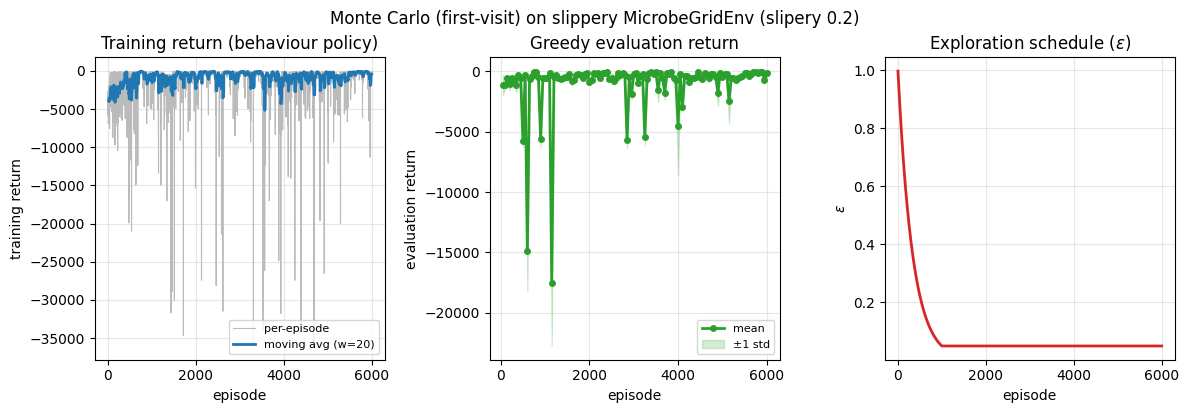

In [15]:
fig = plot_learning_curves(hist_mc_slip)
variant = "every-visit" if MC_PARAMS["every_visit"] else "first-visit"
fig.suptitle(f"Monte Carlo ({variant}) on slippery MicrobeGridEnv ({env_type})",
             y=1.02)
plt.show()

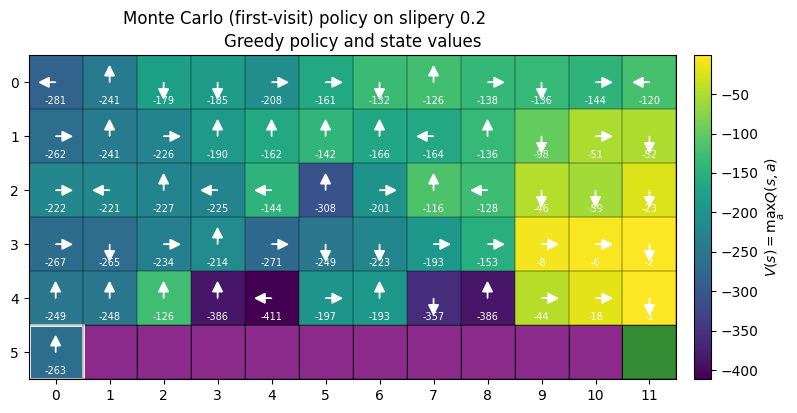

In [16]:
fig = plot_grid_policy_and_values(agent_mc_slip, env_mc_slip,
                                  annotate_values=True)
variant = "every-visit" if MC_PARAMS["every_visit"] else "first-visit"
fig.suptitle(f"Monte Carlo ({variant}) policy on {env_type}", y=1.02)
plt.show()

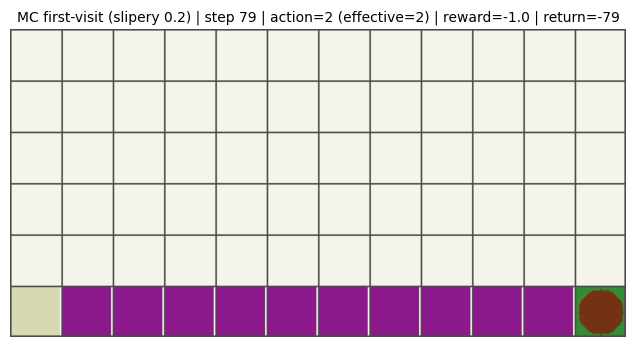

Episode ended after 79 steps with return -79.


In [17]:
def show_frame(frame, title):
    plt.figure(figsize=(10, 4))
    plt.imshow(frame)
    plt.axis("off")
    plt.title(title, fontsize=10)
    plt.show()

FRAME_DELAY = 0.3
ROLLOUT_MAX_STEPS = 80

env_demo = MicrobeGridEnv(**ENV_CONF)
obs, _ = env_demo.reset(seed=MASTER_SEED + 200)
ep_step, ep_return = 0, 0.0
variant = "every-visit" if MC_PARAMS["every_visit"] else "first-visit"

show_frame(env_demo.render(),
           title=f"MC {variant} ({env_type}) | step 0 | return 0")
time.sleep(FRAME_DELAY)

for _ in range(ROLLOUT_MAX_STEPS):
    action = agent_mc_slip.select_action(obs, greedy=True)
    obs, reward, terminated, truncated, info = env_demo.step(action)
    ep_step += 1
    ep_return += reward

    clear_output(wait=True)
    show_frame(
        env_demo.render(),
        title=(f"MC {variant} ({env_type}) | step {ep_step} | "
               f"action={action} (effective={info['effective_action']}) | "
               f"reward={reward} | return={ep_return:.0f}")
    )
    time.sleep(FRAME_DELAY)

    if terminated or truncated:
        break

env_demo.close()
print(f"Episode ended after {ep_step} steps with return {ep_return:.0f}.")

A look at the policy plot reveals something we did not see with the TD methods. The arrows trace a coherent path along most of the grid, but in the lateral regions — the upper rows and the corners far from the goal — small *cycles* appear: a cell points right, the cell to its right points back left; a cell points up, the cell above points back down. A microbe acting greedily from one of these cells would enter the cycle and never escape.

This is not a bug of the implementation, and it is not stochastic noise from a single training run. It is a structural manifestation of how MC propagates — or rather, fails to propagate — information across the state space, made worse by the slippery dynamics.

The cleanest way to see what is going on is to ask: *what would TD do if it were facing the same situation?* Suppose two adjacent cells $s_1$ and $s_2$ have noisy Q-estimates that happen to make the greedy policy point from $s_1$ towards $s_2$ and from $s_2$ back towards $s_1$. Under TD, the very first transition $s_1 \to s_2$ executed during training causes an update of $Q(s_1, \text{right})$ towards $r + \gamma Q(s_2, A_2)$, where $A_2$ is "left". Because the bootstrap term carries information about the value of the cycle's continuation, $Q(s_1, \text{right})$ is immediately pushed downwards if the cycle's onward value is low. *TD breaks the cycle within a handful of updates*, simply by propagating local consistency between adjacent cells — even cells the agent visits only occasionally.

MC has no such mechanism. It learns exclusively from $G_t$, the return collected from time $t$ until the episode ends. To discover that a cycle between $s_1$ and $s_2$ is bad, MC needs an episode in which the agent actually enters the cycle, lingers there for many steps, and finally escapes thanks to an $\varepsilon$-exploration. Only then does the corresponding $G_t$ reflect the cost of the wasted steps. With $\varepsilon$ small, such episodes are rare; with the cycle in a region of the grid the policy visits seldom, they are rarer still. *MC is efficient at propagating information within an observed episode, but blind to regions the policy itself does not traverse*.

The slippery dynamics aggravate the problem in two ways. They inflate the variance of every $G_t$, which means that even when MC does receive a sample from a lateral region, the signal is noisy. They also make the lengths of episodes more variable, so that the contribution of any single $(s, a)$ visit to its $G_t$ can swing widely depending on how the rest of the episode unfolds. Q-estimates in lateral regions therefore differ from each other by amounts smaller than the residual noise, and the greedy argmax across the four actions is essentially randomised — exactly the regime in which inconsistencies between neighbouring cells produce visible cycles.

A subtle but important observation is that switching to the constant step size $\alpha = 0.1$, which we are using here, does *not* eliminate the problem. The constant step size cures a different MC pathology — the "harmonic memory" of $\alpha = 1/N$, which would let very early random-policy returns contribute to current estimates indefinitely — but it does not address the absence of bootstrap. Cycles in the lateral regions are a signature of the absence of bootstrap, not of the step-size schedule. They would persist with any reasonable $\alpha$.

The methodological lesson is to read the policy plot of an MC-trained agent with awareness that the *informative* arrows are the ones along trajectories the policy actually traverses. In the lateral regions, the arrows reflect the algorithm's uncertainty more than its considered preferences. A practical consequence is that greedy evaluation rollouts will occasionally enter such loops and never reach the goal: those episodes dominate the high-variance tail of the evaluation distribution and are part of the reason MC's evaluation curve has wider bands than the TD ones.

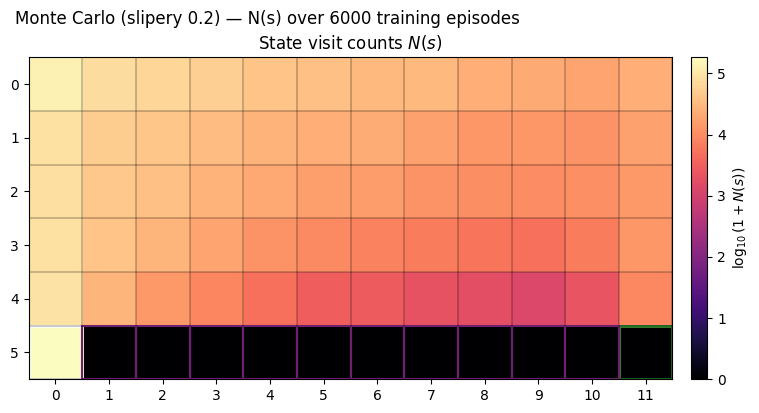

In [18]:
fig = plot_state_visits(env_mc_slip.state_action_counts, env_mc_slip)
fig.suptitle(f"Monte Carlo ({env_type}) — N(s) over {N_EPISODES} training episodes",
             y=1.02)
plt.show()

## Closing notes: when to use which?

The three algorithms we have studied — Q-learning, SARSA, Monte Carlo — sit at three corners of a small but consequential design space. A practitioner choosing among them is implicitly answering three questions, and it is worth surfacing them explicitly.

### Three axes of choice

**On-policy or off-policy?** SARSA and MC evaluate the policy they actually follow during training; Q-learning evaluates the greedy policy regardless of what the agent is doing. Off-policy methods learn the best policy *as if* the agent were already optimal, which is what we usually want at convergence — but during training, they ignore the cost of the exploration that is happening. On-policy methods learn the value of the current behaviour including its exploration, which makes them more *robust during training* on stochastic problems but slightly more *conservative at convergence*.

**Bootstrap or full return?** TD methods (both Q-learning and SARSA) estimate from one-step transitions, building each target on top of the current Q-estimate. MC waits for an entire episode and uses the realised return. TD has lower variance and propagates information immediately between adjacent state-action pairs (the bootstrap term is what breaks the cycles we saw in MC); MC is unbiased and immune to bootstrapping artifacts. Bootstrapping is the more powerful tool whenever propagation between neighbouring states matters, which on most problems is essentially always.

**Running mean or constant step size?** Tabular MC's textbook estimator uses $\alpha = 1/N(s, a)$, which is the right thing for *prediction* under a fixed policy but not for *control*, where the policy changes during training. A constant step size $\alpha$ — typical for TD methods — implements an exponentially-decaying memory that adapts to the moving target. The optimal $\alpha$ depends on how non-stationary the target is and how noisy the samples are; in practice values in $[0.05, 0.5]$ are reasonable defaults to try.

### Practical guidance

Some situations have clear preferences.

**Episodic, stochastic, with risky regions.** SARSA tends to be the safest choice. The on-policy nature absorbs the cost of $\varepsilon$-exploration into the value function, producing policies that are robust to the agent's own randomness — exactly what we saw on slippery `MicrobeGridEnv`. Q-learning still works, but during training it operates "under the illusion" that exploration will not happen, which can be dangerous in real systems where mistakes are costly.

**Episodic, near-deterministic.** Q-learning is typically fastest, because its off-policy target removes the exploration noise from the learning signal, and the noise was small to begin with. SARSA and Q-learning converge to similar policies anyway in this regime, so the off-policy speed advantage prevails.

**Continuing tasks (no natural episode termination).** MC is structurally inapplicable: there is no $G_t$ without a termination. TD methods are the only option, and the choice between Q-learning and SARSA reverts to the on/off-policy axis discussed above.

**Need to learn from data collected by another policy.** Off-policy methods are the only option. Q-learning is the canonical answer in the tabular setting; we will see in Lecture 5 how this generalises to deep RL with experience replay, which is essentially "learning off-policy from a buffer of past transitions".

**Need to evaluate a fixed policy from rollouts.** This is the *prediction* problem rather than *control*. MC with running mean ($\alpha = 1/N$) is the textbook unbiased answer; it has no bias from non-stationarity because the policy is fixed. TD methods are also valid and converge faster in practice, at the cost of a small bias from imperfect bootstrap.

**High-stakes or high-cost transitions during training.** SARSA, again, is preferable. The on-policy property means the agent's value function is *honest* about the cost of its current behaviour, including exploration; an SARSA-trained system can be deployed mid-training with realistic expectations of its actual performance. A Q-learning-trained system mid-training has values that overestimate what it will actually achieve while still exploring.

### What carries over, what does not

Two of the three axes — on-policy vs. off-policy, bootstrap vs. full-return — generalise cleanly to function approximation, which is the topic of the rest of the course. SARSA-style and Q-learning-style updates with linear or neural function approximators retain the same conceptual roles: the on-policy versions are conservative and robust, the off-policy versions are aggressive and faster on stochastic problems but more prone to instability. We will see in Lecture 4 that combining off-policy targets with function approximation introduces a new class of failure modes — the *deadly triad* — that does not arise in the tabular setting.

The third axis — running mean vs. constant step — disappears in deep RL. Neural networks are trained with explicit gradient steps under a chosen optimiser; the analogue of "$\alpha$" becomes the optimiser's learning rate, governed by Adam, RMSprop, or SGD with momentum. The conceptual lesson — that the step size encodes a memory length, and that this memory must be calibrated to the non-stationarity of the target — survives, but its implementation is hidden inside whatever modern optimiser is in use.

The takeaway is that the tabular methods we have studied are not a self-contained chapter but the foundation on which the rest of the course will build. The names will change — semi-gradient TD, deep Q-networks, double DQN — but the questions they answer are the same three questions we have just listed. Knowing which question each method is answering is what lets you pick the right tool when you face a new problem.